In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_parquet("data/flights_economy_1gb")

In [3]:
data.columns

Index(['legId', 'searchDate', 'flightDate', 'startingAirport',
       'destinationAirport', 'numDaysToFlight', 'numLayovers',
       'layoverDurationMinutes', 'seatsRemaining', 'travelDuration',
       'totalTravelDistance', 'elapsedDays', 'isBasicEconomy', 'isRefundable',
       'isNonStop', 'baseFare', 'totalFare', 'segmentsDepartureTime',
       'segmentsArrivalTime', 'segmentsArrivalAirportCode',
       'segmentsDepartureAirportCode', 'segmentsAirlineName',
       'segmentsAirlineCode', 'segmentsAircraft', 'segmentsDurationInMinutes',
       'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

In [4]:
y = data.totalFare

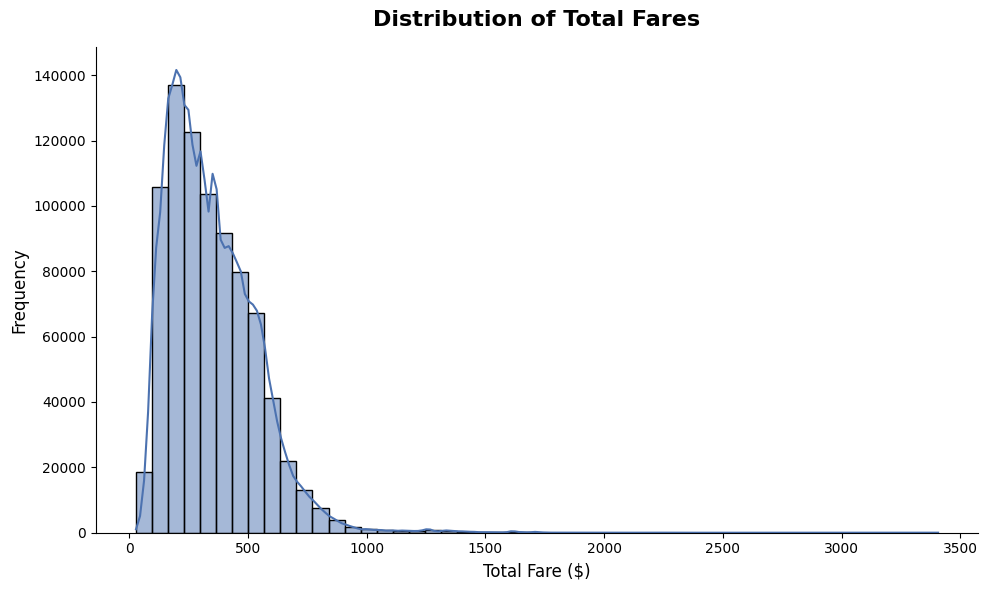

In [5]:
# [CELL 1] Distribution of Total Fare
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram with KDE
sns.histplot(data=data, x='totalFare', bins=50, kde=True, color='#4C72B0', ax=ax)

# Aesthetics
ax.set_title("Distribution of Total Fares", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Total Fare ($)", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

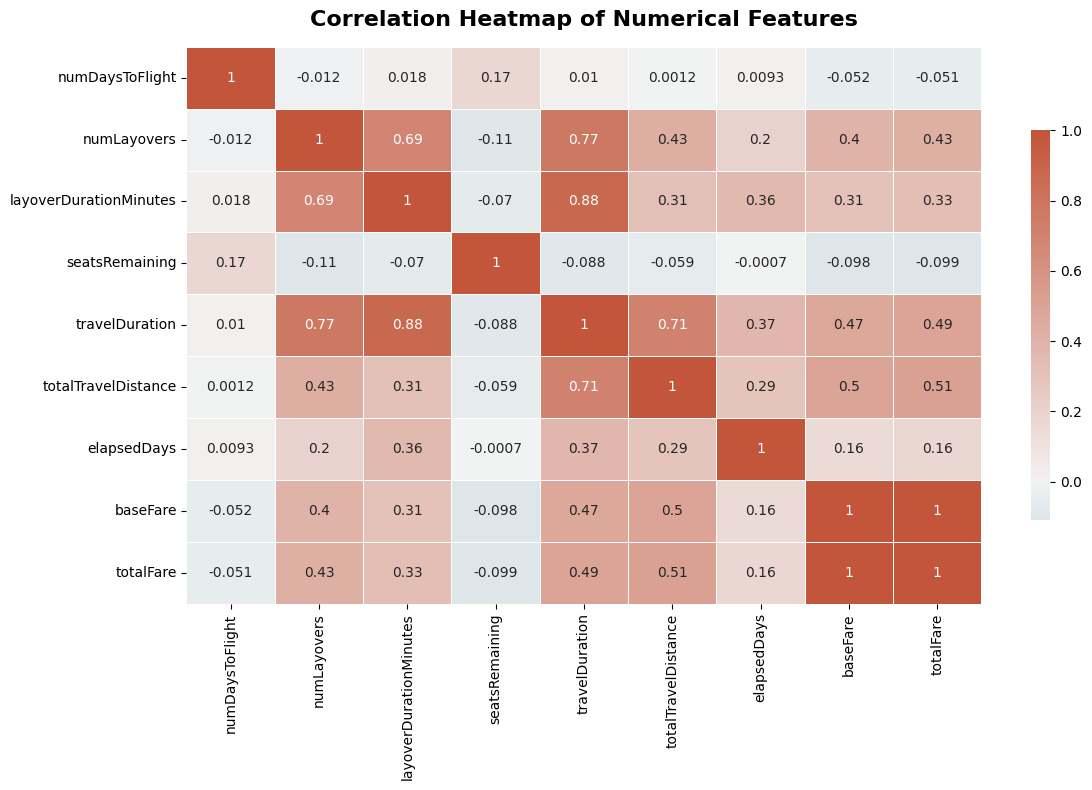

In [8]:
# [CELL 2] Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Select only numerical columns to avoid errors
num_cols = data.select_dtypes(include=[np.number]).columns
corr_matrix = data[num_cols].corr()

# Create a custom diverging colormap and plot
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr_matrix, cmap=cmap, center=0, annot=True, 
            linewidths=.5, cbar_kws={"shrink": .7}, ax=ax)

ax.set_title("Correlation Heatmap of Numerical Features", fontsize=16, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

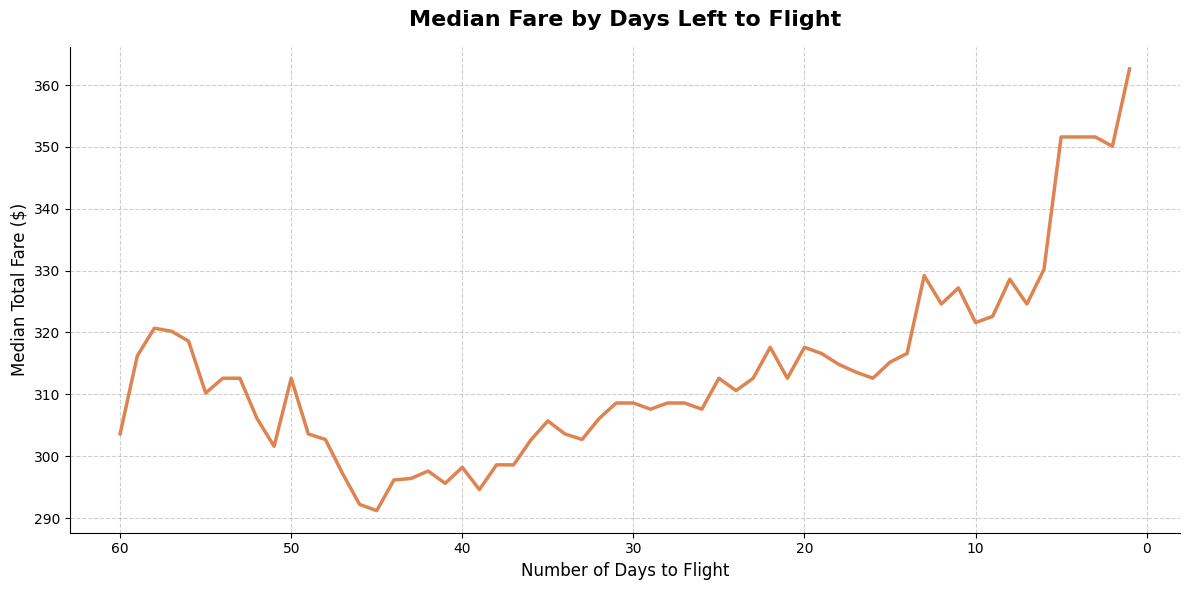

In [7]:
# [CELL 3] Trend: Number of Days to Flight vs Fare
fig, ax = plt.subplots(figsize=(12, 6))

# Calculate median fare for each 'numDaysToFlight'
days_trend = data.groupby('numDaysToFlight')['totalFare'].median().reset_index()

sns.lineplot(data=days_trend, x='numDaysToFlight', y='totalFare', 
             color='#DD8452', linewidth=2.5, ax=ax)

# Aesthetics
ax.set_title("Median Fare by Days Left to Flight", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Number of Days to Flight", fontsize=12)
ax.set_ylabel("Median Total Fare ($)", fontsize=12)
ax.invert_xaxis()  # Invert so right side approaches day 0 (departure)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

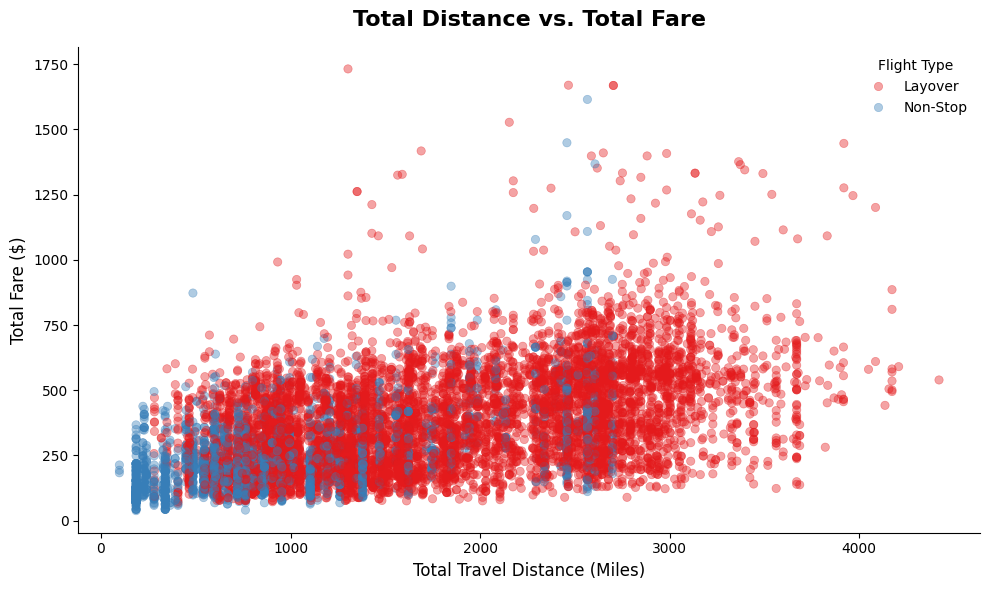

In [9]:
# [CELL 4] Distance vs. Fare (colored by Non-Stop vs Layover)
fig, ax = plt.subplots(figsize=(10, 6))

# Using a sample if the dataset is too large to prevent overplotting/crashing
plot_data = data.sample(n=10000, random_state=42) if len(data) > 10000 else data

sns.scatterplot(data=plot_data, x='totalTravelDistance', y='totalFare', 
                hue='isNonStop', palette='Set1', alpha=0.4, edgecolor=None, ax=ax)

ax.set_title("Total Distance vs. Total Fare", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Total Travel Distance (Miles)", fontsize=12)
ax.set_ylabel("Total Fare ($)", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['Layover', 'Non-Stop'], title="Flight Type", frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# [CELL 5] Fare Distribution by Airline
fig, ax = plt.subplots(figsize=(12, 6))

# Get top 10 airlines by volume to keep the plot readable
top_airlines = data['segmentsAirlineName'].value_counts().nlargest(10).index
filtered_airlines = data[data['segmentsAirlineName'].isin(top_airlines)]

sns.boxplot(data=filtered_airlines, x='segmentsAirlineName', y='totalFare', 
            palette='viridis', fliersize=1, ax=ax)

ax.set_title("Fare Distribution by Top 10 Airlines", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Airline Name", fontsize=12)
ax.set_ylabel("Total Fare ($)", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [ ]:
# [CELL 6] Impact of Binary Features on Fare
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Basic Economy
sns.barplot(data=data, x='isBasicEconomy', y='totalFare', estimator=np.median, 
            ci=None, palette='pastel', ax=axes[0])
axes[0].set_title("Basic Economy vs Fare")
axes[0].set_xticklabels(['Standard', 'Basic Economy'])

# Plot 2: Refundable
sns.barplot(data=data, x='isRefundable', y='totalFare', estimator=np.median, 
            ci=None, palette='pastel', ax=axes[1])
axes[1].set_title("Refundability vs Fare")
axes[1].set_xticklabels(['Non-Refundable', 'Refundable'])

# Plot 3: Non-Stop
sns.barplot(data=data, x='isNonStop', y='totalFare', estimator=np.median, 
            ci=None, palette='pastel', ax=axes[2])
axes[2].set_title("Direct vs Layovers vs Fare")
axes[2].set_xticklabels(['Has Layovers', 'Non-Stop'])

# Clean up all axes
for ax in axes:
    ax.set_ylabel("Median Total Fare ($)")
    ax.set_xlabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# [CELL 7] Layovers vs Total Fare
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=data, x='numLayovers', y='totalFare', 
               palette='muted', inner='quartile', ax=ax)

ax.set_title("Distribution of Fares by Number of Layovers", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Number of Layovers", fontsize=12)
ax.set_ylabel("Total Fare ($)", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# [CELL 8] Time Series of Fares by Flight Date
fig, ax = plt.subplots(figsize=(14, 6))

# Ensure flightDate is a datetime object
data['flightDate_dt'] = pd.to_datetime(data['flightDate'])

# Calculate daily median fare
daily_fare = data.groupby('flightDate_dt')['totalFare'].median().reset_index()

sns.lineplot(data=daily_fare, x='flightDate_dt', y='totalFare', 
             color='#2CA02C', linewidth=2, ax=ax)

ax.set_title("Median Fare Over Time (By Flight Date)", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Flight Date", fontsize=12)
ax.set_ylabel("Median Total Fare ($)", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Format x-axis dates nicely
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()